In [1]:
import sys
sys.path.append('../')
from pprint import pprint

In [2]:
# Define system

from eq_solver.system import Species, Component, Equilibrium, System, Phase, Constraint

H = Species(name='H+', phase=Phase.LIQUID)
OH = Species(name='OH-', phase=Phase.LIQUID)
Na = Species(name='Na+', phase=Phase.LIQUID)
Cl = Species(name='Cl-', phase=Phase.LIQUID)

sodium = Component(name='sodium', constraint=Constraint.DIRECT, base_species=Na, base_charge=+1)
proton = Component(name='proton', constraint=Constraint.CHARGE, base_species=H, base_charge=+1)
chloride = Component(name='chloride', constraint=Constraint.DIRECT, base_species=Cl, base_charge=-1)

eq = Equilibrium('Kw', stoichiometry={H: 1, OH: 1}, logK=-14.0, DH=57.0)

In [3]:
# Solve for different temperatures

import numpy as np
from eq_solver import Conditions, FitFunc

t_list = np.linspace(0, 100, 21)

s_base = System(activity_model='none', species=(H, OH, Na, Cl), components=(sodium, proton, chloride), equilibria=(eq,), temperature=298.15)
# logK at different temperature is calculated via van 't Hoff equation.
s_list = [s_base.with_temperature(273.15 + t) for t in t_list]

# 0.001 mol/L HCl
cond_list_hcl = [Conditions.from_dict(s, {'chloride': 0.001, 'sodium': 0.0}) for s in s_list]
res_list_hcl = [FitFunc(s, c).solve() for s, c in zip(s_list, cond_list_hcl)]

# 0.001 mol/L NaOH
cond_list_naoh = [Conditions.from_dict(s, {'chloride': 0.0, 'sodium': 0.001}) for s in s_list]
res_list_naoh = [FitFunc(s, c).solve() for s, c in zip(s_list, cond_list_naoh)]

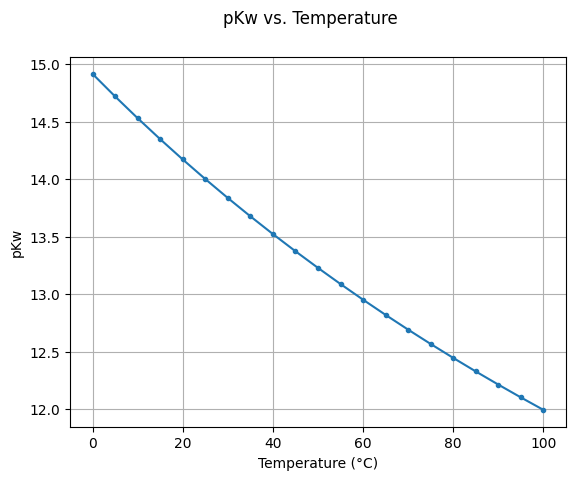

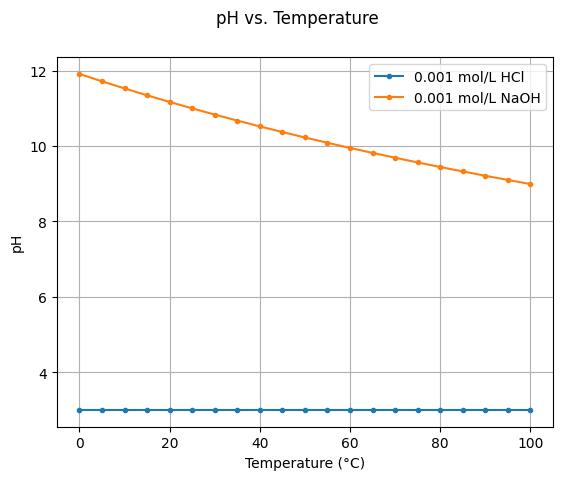

In [4]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_list, [-s.equilibria[0].logK for s in s_list], '.-')
plt.grid()
plt.xlabel('Temperature (°C)')
plt.ylabel('pKw')
plt.suptitle('pKw vs. Temperature')
plt.show()

plt.figure()
plt.suptitle('pH vs. Temperature')
plt.plot(t_list, [r.pH() for r in res_list_hcl], '.-', label='0.001 mol/L HCl')
plt.plot(t_list, [r.pH() for r in res_list_naoh], '.-', label='0.001 mol/L NaOH')
plt.legend()
plt.grid()
plt.xlabel('Temperature (°C)')
plt.ylabel('pH')
plt.show()